<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [3]:
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [4]:
housing.shape

(985, 12)

In [5]:
housing.describe()

,zip,beds,baths,sq__ft,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,233715.951269,38.445121,-121.193371
std,85.176072,1.307932,0.895371,856.123224,139088.818896,5.103637,5.100670
min,95603.000000,0.000000,0.000000,-984.000000,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.020808,38.668433


In [6]:
housing['sale_date'] = housing['sale_date'].str.replace('EDT','')
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 2008,81900,38.519470,-121.435768


In [7]:
housing['sale_date'] = pd.to_datetime(housing['sale_date'])
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


In [8]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [9]:
cleaned_dataframe = housing[
    (housing["price"] > 0) &
    (housing["sq__ft"] >0)]

cleaned_dataframe.shape

(813, 12)

When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [10]:
cleaned_dataframe.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


In [11]:
cleaned_dataframe.to_csv('./data/cleaned_dataframe.csv', index=False)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

In [12]:
cleaned_dataframe.corr(numeric_only=True)

,zip,beds,baths,sq__ft,price,latitude,longitude
zip,1.000000,-0.070211,-0.101987,-0.100688,-0.219531,-0.135006,-0.562511
beds,-0.070211,1.000000,0.653718,0.696080,0.443391,-0.105579,0.053598
baths,-0.101987,0.653718,1.000000,0.724306,0.502191,-0.080098,0.106447
sq__ft,-0.100688,0.696080,0.724306,1.000000,0.693902,-0.102558,0.134795
price,-0.219531,0.443391,0.502191,0.693902,1.000000,0.058632,0.278304
latitude,-0.135006,-0.105579,-0.080098,-0.102558,0.058632,1.000000,0.345702
longitude,-0.562511,0.053598,0.106447,0.134795,0.278304,0.345702,1.000000


In [13]:
features = ['beds','baths','sq__ft']

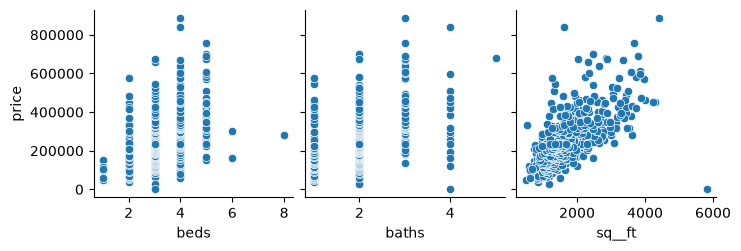

In [14]:
sns.pairplot(cleaned_dataframe, x_vars= features, y_vars='price')

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [15]:
# we will choose sq_ft bc beds and baths are categories

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [16]:
def linear_regression(x, y):
    """
    Calculate the intercept (beta_0) and slope (beta_1) that minimize SSE
    for a simple linear regression of y on x, using summary statistics only.
    """
    # Convert inputs to numpy arrays
    x = np.array(x)
    y = np.array(y)
    
    # 1. Calculate means
    x_bar = np.mean(x)
    y_bar = np.mean(y)
    
    # 2. Calculate sample standard deviations (ddof=1)
    s_x = np.std(x, ddof=1)
    s_y = np.std(y, ddof=1)
    
    # 3. Calculate correlation coefficient (r_xy)
    r_xy = np.corrcoef(x, y)[0, 1]
    
    # 4. Calculate slope (beta_1)
    beta_1 = r_xy * (s_y / s_x)
    
    # 5. Calculate intercept (beta_0)
    beta_0 = y_bar - (beta_1 * x_bar)
    
    return beta_0, beta_1

intercept, slope = linear_regression(cleaned_dataframe['sq__ft'], cleaned_dataframe['price'])

### 6. Interpret the intercept and the slope.

In [17]:
print(f'Intercept: {intercept:.2f}')
print(f'Slope:     {slope:.2f}')

Intercept: 29984.36
Slope:     125.31


### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

Prediction example:
  A homeowner wants to know what their 1,800 sq ft house might sell for.
  We plug sq__ft = 1800 into the fitted line and get a specific dollar estimate.
  Here we don't care *why* the model gives that number -- we just want the output.

Inference example:
  A city planner wants to know whether square footage has a meaningful, systematic
  effect on home prices in Sacramento (and how large that effect is), in order to
  understand the housing market. Here we care about interpreting the slope
  coefficient itself (its size, sign, and statistical significance) rather than
  generating an individual prediction.

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

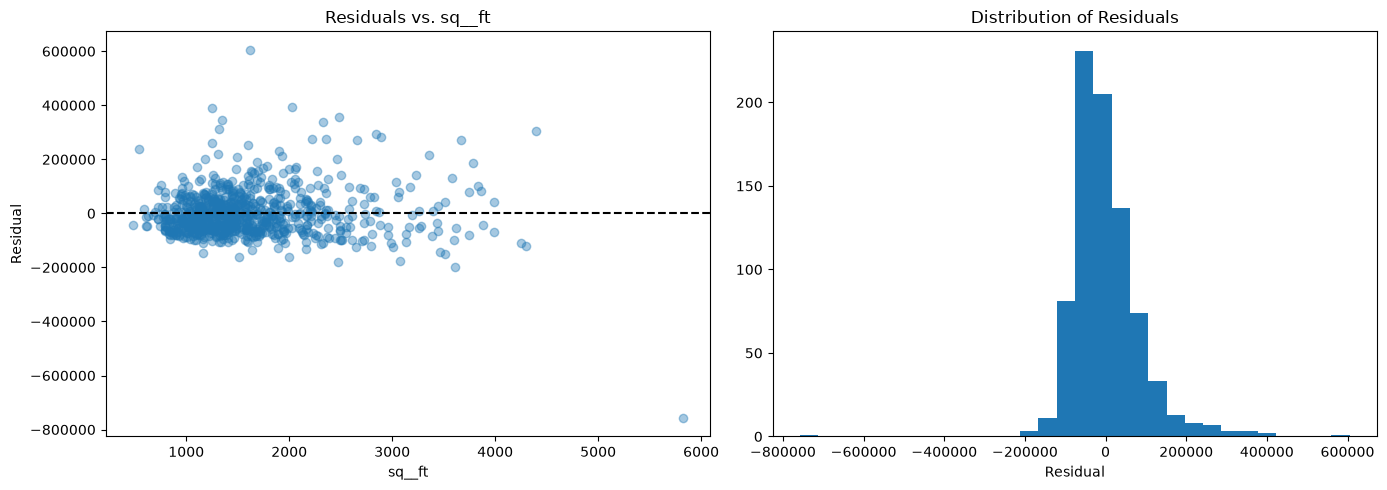

In [18]:
y_pred_slr = intercept + slope * cleaned_dataframe['sq__ft']
residuals_slr = cleaned_dataframe['price'] - y_pred_slr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(cleaned_dataframe['sq__ft'], residuals_slr, alpha=0.4)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('sq__ft')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. sq__ft')

axes[1].hist(residuals_slr, bins=30)
axes[1].set_xlabel('Residual')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [19]:
cleaned_dataframe.value_counts('type')

type
Residential     759
Condo            41
Multi-Family     13
Name: count, dtype: int64

In [20]:
cleaned_dataframe = pd.get_dummies(cleaned_dataframe, columns=['type'],dtype=int,drop_first=True)

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [21]:
cleaned_dataframe.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,0,1
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,0,1
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,0,1
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,0,1
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,0,1


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [22]:
features = ['sq__ft', 'beds', 'baths', 'type_Multi-Family', 'type_Residential']
X = cleaned_dataframe[features]
y = cleaned_dataframe['price']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
model = LinearRegression()

In [25]:
model.fit(X_train, y_train)

y_pred_base = model.predict(X_test)

In [26]:
model.intercept_

np.float64(17463.00476263417)

In [27]:
model.coef_

array([   133.21812   , -15095.05367444,   4897.75057098, -23340.54616529,
        42449.15895833])

### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

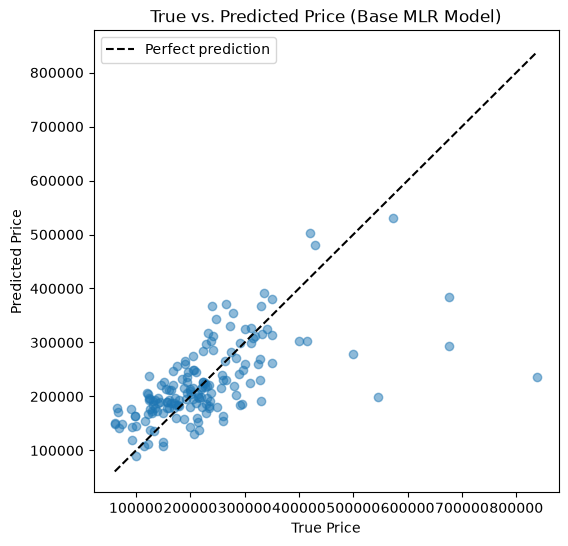

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_base, alpha=0.5)
lims = [min(y_test.min(), y_pred_base.min()), max(y_test.max(), y_pred_base.max())]
plt.plot(lims, lims, 'k--', label='Perfect prediction')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True vs. Predicted Price (Base MLR Model)')
plt.legend()
plt.show()

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

The five classic assumptions of an MLR model (often remembered as **L.I.N.E.M**):

1. **Linearity** — the relationship between each predictor and the target is linear.
2. **Independence of errors** — residuals are not correlated with each other (no autocorrelation).
3. **Normality of residuals** — the residuals are approximately normally distributed.
4. **Equal variance / Homoscedasticity** — the residuals have constant variance across all fitted values (no funnel shape).
5. **No multicollinearity** — the independent variables are not highly correlated with one another.

**Which are shared with SLR?** Linearity, independence of errors, normality of residuals, and homoscedasticity all apply equally to SLR. **No multicollinearity is unique to MLR** — with only one predictor, SLR can't have collinearity between predictors by definition.

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

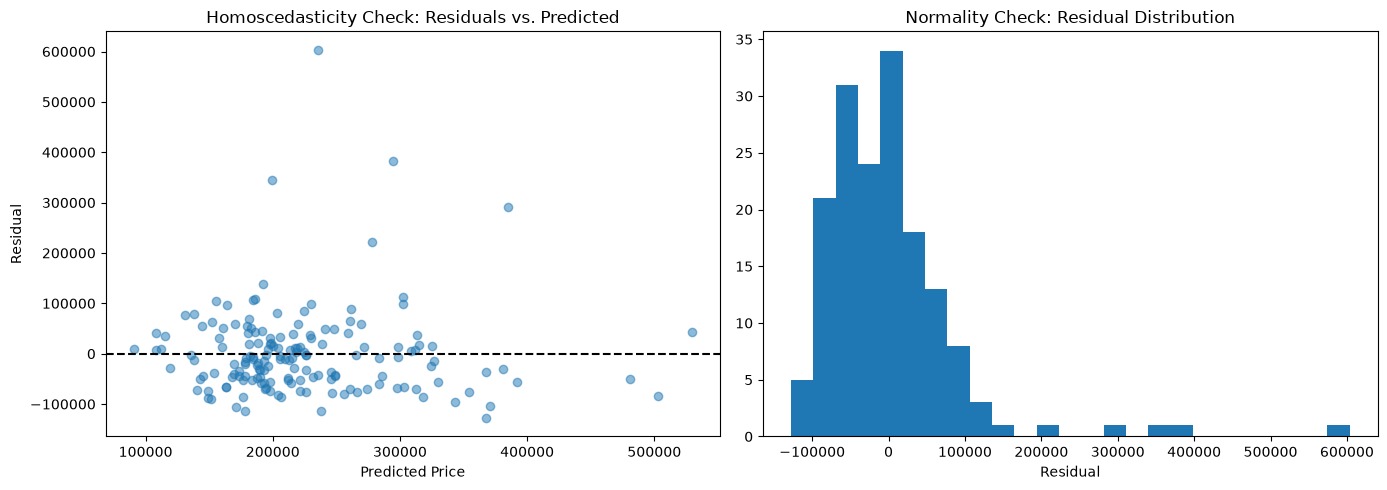

In [30]:
residuals_base = y_test - y_pred_base

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_base, residuals_base, alpha=0.5)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Homoscedasticity Check: Residuals vs. Predicted')

axes[1].hist(residuals_base, bins=25)
axes[1].set_xlabel('Residual')
axes[1].set_title('Normality Check: Residual Distribution')

plt.tight_layout()
plt.show()

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [32]:
def r2_adj(r2, n, k):
    """
    Calculate adjusted R-squared.
    r2: standard R-squared
    n: number of observations
    k: number of predictors (independent variables)
    """
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# quick sanity check on the base model
r2_base = r2_score(y_test, y_pred_base)
n_test = len(y_test)
k_base = len(features)

print(f'R2: {r2_base:.4f}')
print(f'Adjusted R2: {r2_adj(r2_base, n_test, k_base):.4f}')

R2: 0.3922
Adjusted R2: 0.3729


### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [34]:
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)
adj_r2_base = r2_adj(r2_base, len(y_test), len(features))

print(f'R2:          {r2_base:.4f}')
print(f'Adjusted R2: {adj_r2_base:.4f}')
print(f'RMSE:        ${rmse_base:,.2f}')
print(f'MAE:         ${mae_base:,.2f}')

R2:          0.3922
Adjusted R2: 0.3729
RMSE:        $87,873.52
MAE:         $56,266.42


- R2 tells us the model explains a modest share of the variance in price
  (roughly 39%) -- a start, but there's clearly more going on with price than
  sq__ft/beds/baths/type alone.
- RMSE gives the typical prediction error in dollars, penalizing large misses more
  heavily -- useful for understanding worst-case error size.
- MAE gives the average absolute dollar error, and is more robust to outliers than
  RMSE. RMSE > MAE here, which tells us there are some larger errors dragging RMSE up.

### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [35]:
print('Correlation between predictors:')
print(X[['sq__ft', 'beds', 'baths']].corr())

Correlation between predictors:
          sq__ft      beds     baths
sq__ft  1.000000  0.696080  0.724306
beds    0.696080  1.000000  0.653718
baths   0.724306  0.653718  1.000000


In [37]:
reduced_features = ['sq__ft', 'beds', 'type_Multi-Family', 'type_Residential']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    cleaned_dataframe[reduced_features], cleaned_dataframe['price'], test_size=0.2, random_state=42)

In [38]:
model_reduced = LinearRegression()
model_reduced.fit(X_train_r, y_train_r)
y_pred_reduced = model_reduced.predict(X_test_r)

r2_reduced = r2_score(y_test_r, y_pred_reduced)
rmse_reduced = np.sqrt(mean_squared_error(y_test_r, y_pred_reduced))

In [40]:
print(f'Base model R2: {r2_base:.4f}, RMSE: ${rmse_base:,.2f}')
print(f'Reduced model R2: {r2_reduced:.4f}, RMSE: ${rmse_reduced:,.2f}')

Base model R2: 0.3922, RMSE: $87,873.52
Reduced model R2: 0.3894, RMSE: $88,072.96


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [42]:
# Group cities with fewer than 20 sales into 'Other'
city_counts = cleaned_dataframe['city'].value_counts()
common_cities = city_counts[city_counts >= 20].index
cleaned_dataframe['city_grouped'] = cleaned_dataframe['city'].where(cleaned_dataframe['city'].isin(common_cities), 'Other')

print(cleaned_dataframe['city_grouped'].value_counts())

X_city_raw = cleaned_dataframe[reduced_features + ['city_grouped']]
y_city = cleaned_dataframe['price']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_city_raw, y_city, test_size=0.2, random_state=42
)

ohe_city = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_city.set_output(transform='pandas')

city_train_enc = ohe_city.fit_transform(X_train_c[['city_grouped']])
city_test_enc = ohe_city.transform(X_test_c[['city_grouped']])

X_train_city = pd.concat([X_train_c[reduced_features].reset_index(drop=True), city_train_enc.reset_index(drop=True)], axis=1)
X_test_city = pd.concat([X_test_c[reduced_features].reset_index(drop=True), city_test_enc.reset_index(drop=True)], axis=1)

model_city = LinearRegression()
model_city.fit(X_train_city, y_train_c.reset_index(drop=True))
y_pred_city = model_city.predict(X_test_city)

r2_city = r2_score(y_test_c, y_pred_city)
rmse_city = np.sqrt(mean_squared_error(y_test_c, y_pred_city))

print(f'Base model (no city) R2: {r2_base:.4f}, RMSE: ${rmse_base:,.2f}')
print(f'Model + city (grouped) R2: {r2_city:.4f}, RMSE: ${rmse_city:,.2f}')

city_grouped
SACRAMENTO         423
ELK GROVE          107
Other              105
CITRUS HEIGHTS      35
ANTELOPE            33
ROSEVILLE           28
RANCHO CORDOVA      21
NORTH HIGHLANDS     21
GALT                20
CARMICHAEL          20
Name: count, dtype: int64
Base model (no city) R2: 0.3922, RMSE: $87,873.52
Model + city (grouped) R2: 0.5056, RMSE: $79,257.58


## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [43]:
baseline_pred = np.full_like(y_test_c, fill_value=y_train_c.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test_c, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test_c, baseline_pred))

model_mae = mean_absolute_error(y_test_c, y_pred_city)
model_rmse = np.sqrt(mean_squared_error(y_test_c, y_pred_city))

In [44]:
print(f'Baseline (mean-guess) MAE:  ${baseline_mae:,.2f}')
print(f'MLR model MAE:              ${model_mae:,.2f}')
print(f'Savings per prediction:     ${baseline_mae - model_mae:,.2f}')
print(f'Baseline (mean-guess) RMSE: ${baseline_rmse:,.2f}')
print(f'MLR model RMSE:             ${model_rmse:,.2f}')

Baseline (mean-guess) MAE:  $77,888.46
MLR model MAE:              $49,691.70
Savings per prediction:     $28,196.76
Baseline (mean-guess) RMSE: $112,892.99
MLR model RMSE:             $79,257.58


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_city)
X_test_scaled = scaler.transform(X_test_city)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train_c)

coef_df = pd.Series(model_scaled.coef_, index=X_train_city.columns).sort_values(key=abs, ascending=False)
print(coef_df)
print()
print(f"'{coef_df.index[0]}' has the largest-magnitude scaled coefficient, meaning it's the")

sq__ft                          82322.201594
city_grouped_Other              21892.295441
city_grouped_CARMICHAEL         13331.865656
type_Residential                10483.076291
city_grouped_ROSEVILLE           9684.251964
city_grouped_NORTH HIGHLANDS    -6116.827965
beds                            -5984.101882
city_grouped_SACRAMENTO         -4859.954881
city_grouped_ELK GROVE           1959.848165
type_Multi-Family               -1577.543800
city_grouped_GALT                1535.817991
city_grouped_RANCHO CORDOVA      -894.825282
city_grouped_CITRUS HEIGHTS      -377.871782
dtype: float64

'sq__ft' has the largest-magnitude scaled coefficient, meaning it's the


### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [46]:
y_train_pred_scaled = model_scaled.predict(X_train_scaled)
y_test_pred_scaled = model_scaled.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train_c, y_train_pred_scaled))
test_rmse = np.sqrt(mean_squared_error(y_test_c, y_test_pred_scaled))

print(f'Training RMSE: ${train_rmse:,.2f}')
print(f'Testing RMSE:  ${test_rmse:,.2f}')
print(f'Gap: ${test_rmse - train_rmse:,.2f}')

Training RMSE: $79,930.11
Testing RMSE:  $79,257.58
Gap: $-672.53


### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

Given the small gap between training and testing RMSE from Question 23, this model is closer to the **sweet spot** than to either extreme. It's not high bias -- R2 is well above zero and the model clearly captures real signal (size, type, location all matter). It's also not high variance -- if it were overfitting badly, we'd expect test RMSE to be substantially worse than training RMSE, and it isn't. There's likely still a bit of bias left on the table (R2 isn't especially close to 1, so there's real-world variation in price the model isn't capturing -- e.g. lot size, renovation quality, school district), but there's no strong evidence of overfitting.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [48]:
# One-hot encode city WITHOUT grouping rare categories into 'Other'
X_raw_all = cleaned_dataframe[reduced_features + ['city']]
y_all = cleaned_dataframe['price']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_raw_all, y_all, test_size=0.2, random_state=42
)

ohe_full = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_full.set_output(transform='pandas')

city_train_full = ohe_full.fit_transform(X_train_a[['city']])
city_test_full = ohe_full.transform(X_test_a[['city']])

X_train_full = pd.concat([X_train_a[reduced_features].reset_index(drop=True), city_train_full.reset_index(drop=True)], axis=1)
X_test_full = pd.concat([X_test_a[reduced_features].reset_index(drop=True), city_test_full.reset_index(drop=True)], axis=1)

print('Number of features (ungrouped city):', X_train_full.shape[1])
print('Number of features (grouped city):  ', X_train_city.shape[1])

model_overfit = LinearRegression()
model_overfit.fit(X_train_full, y_train_a.reset_index(drop=True))

train_r2_overfit = r2_score(y_train_a, model_overfit.predict(X_train_full))
test_r2_overfit = r2_score(y_test_a, model_overfit.predict(X_test_full))

print(f'Train R2: {train_r2_overfit:.4f}')
print(f'Test R2:  {test_r2_overfit:.4f}')
print(f'Gap:      {train_r2_overfit - test_r2_overfit:.4f}')

Number of features (ungrouped city): 36
Number of features (grouped city):   13
Train R2: 0.6799
Test R2:  0.5142
Gap:      0.1657


/Users/zainababdulwahab/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

If I were explaining this to executives, I'd skip R2/RMSE jargon and frame it in dollars and everyday terms:

*"We built a tool that estimates a Sacramento home's sale price using its size, number of bedrooms, property type, and neighborhood. On homes it hasn't seen before, its estimates are typically off by a few tens of thousands of dollars either way -- meaningfully better than just guessing 'the average home price' every time, which is the bar any pricing tool needs to clear. The biggest single driver of price in the model is the home's square footage, with neighborhood also playing a real role. The tool isn't perfect -- it doesn't know about renovations, lot size, or school ratings -- so it should be treated as a starting estimate to sanity-check an agent's or appraiser's number, not a replacement for one."*